Let's implement the following models, all driven by 1-3 independent/correlated brownian motions. In the future, one of them will become fractional. 

(1) "The dynamics of stochastic volatility: evidence from underlying and options markets" - Jones, p.186: $W^1, W^2$ independent,

$$ \mathrm{d}S_t = \mu S_t \mathrm{d}t + \sqrt{V_t} S_t \mathrm{d}W^1_t, \qquad \mathrm{d}V_t = (\alpha + \beta V_t)\mathrm{d}t + \sigma_1 V_t^{\gamma_1} \mathrm{d}W^1_t + \sigma_2 V_t^{\gamma_2} \mathrm{d}W^2_t $$

(I guess without the drift in the equation for $S_t$)

(2) "The quadratic rough Heston model and the joint S&P 500/VIX smile calibration problem" - Gatheral, Jusselin, Rosenbaum, p.3-4 (non-Volterra version):

$$ \mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W_t \qquad \mathrm{d}Z_t = \lambda (\theta(s) - Z_t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \mathrm{d} W_t $$



For later:

(3) "Fast Ninomiya-Victoir calibration of the Double-Mean-Reverting Model" - Bayer, Gatheral, Karlsmark, p.2: $W^1, W^2, W^3$ correlated $\mathrm{d}W^i_t \mathrm{d}W^j_t = \rho^{ij}\mathrm{d} t$,

$$ \mathrm{d} S_t = \sqrt{V_t} S_t \mathrm{d}W^1, \qquad \mathrm{d} v_t = \kappa_1 (V_t' - V_t)\mathrm{d}t + \xi_1 V_t^{\alpha_1} \mathrm{d}W^2_t, \qquad \mathrm{d} V'_t = \kappa_2 (\vartheta - V_t') \mathrm{d}t + \xi_2 V_t^{\alpha_2}\mathrm{d}W^3_t $$

(4) "Rough multifactor volatility for SPX and VIX options" - Jacquier, Muguruza, Pannier, p.4

$$ \mathrm{d} S_t = \sqrt{V_t} S_t \mathrm{d}W^1? \qquad V_t = V_0 \Big[\chi \exp \Big( \nu W^1_t + \frac{\nu^2}{2} t^{2H} \Big) + (1-\chi) \exp \Big( \eta W^1_t + \frac{\eta^2}{2} t^{2H} \Big) \Big] $$

What's the equation for $V$? It can be tested against the expression above.

In [1]:
# Imports
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import *
from controls import *

In [2]:
# Global default parameters
t0, t1 = 0, 1
epsilon = 0.0001
lag = 1.2*epsilon
solver_epsilon = 0.01*epsilon
times = jnp.arange(t0, t1, epsilon)
num_samples = 5
dim_bm = 2

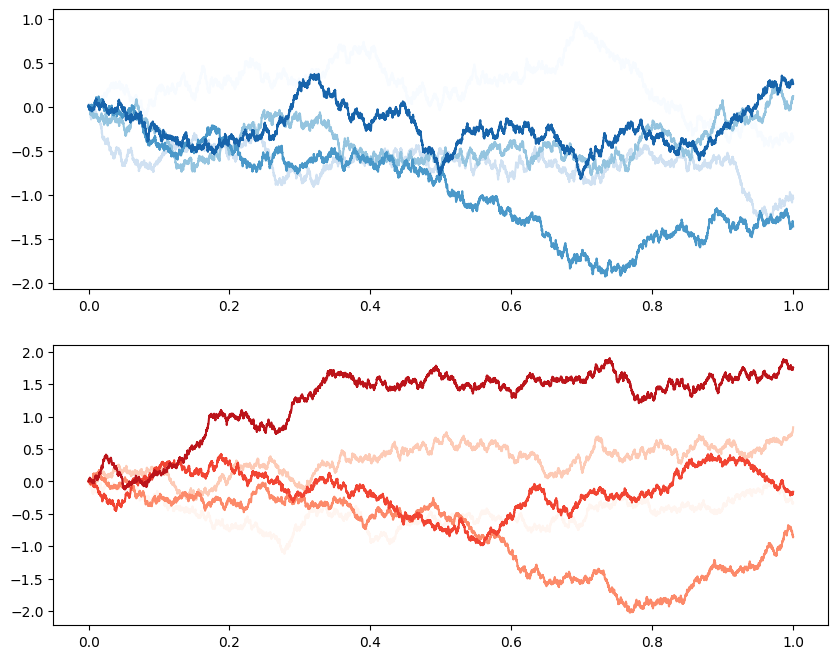

In [104]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot evaluated_batch_vbt[:, :, 0] in shades of blue
for i in range(evaluated_batch_vbt.shape[1]):
    axs[0].plot(times, evaluated_batch_vbt[:, i, 0], color=plt.cm.Blues(i / evaluated_batch_vbt.shape[1]))

# Plot evaluated_batch_vbt[:, :, 1] in shades of red
for i in range(evaluated_batch_vbt.shape[1]):
    axs[1].plot(times, evaluated_batch_vbt[:, i, 1], color=plt.cm.Reds(i / evaluated_batch_vbt.shape[1]))

plt.show()

In [3]:
# (1) Dynamics of stoch vol

gamma1 = 1
gamma2 = 1
sigma1 = 1
sigma2 = 1
alpha = 1
beta = 1

# first the SDE for the vol

y0 = jnp.array([1, 1])
drift_jones = lambda t, y, args: jnp.array([0, alpha + beta*y[1]])
diffusion_jones = lambda t, y, args: jnp.array([[jnp.sqrt(y[1])*y[0], 0], [sigma1*jnp.power(y[1], gamma1), sigma2*jnp.power(y[1], gamma2)]])
saveat = SaveAt(ts = times)


In [6]:
key=jr.PRNGKey(509)
split_key = jax.random.split(key, num_samples)
solutions = vmap_batch_solve(split_key, epsilon, dim_bm, drift_jones, diffusion_jones, y0, Midpoint(), t0, t1, solver_epsilon, saveat)

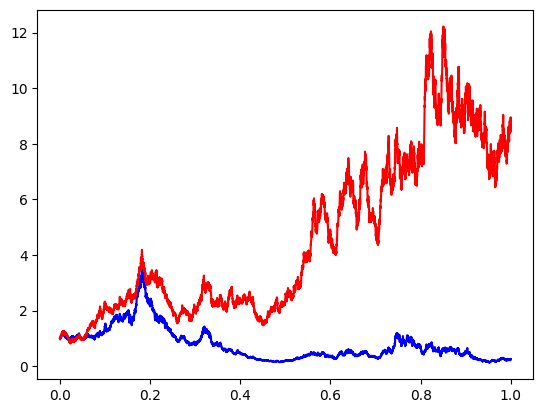

In [7]:
a, b = 0, 10000
path = 0
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 0], color = "blue")
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 1], color = "red")

In [10]:
# (2) Quadratic rough Heston

a = 1
b = 1
c = 1
theta = 1
lam = 1
eta = 1

dim_bm = 1
y0 = jnp.array([1, 1])
drift_qrh = lambda t, y, args: jnp.array([0, lam*(theta - y[1])])
diffusion_qrh = lambda t, y, args: jnp.array([[ y[0] * jnp.sqrt( a * jnp.square( y[1] - b )+ c ) ], [ lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c ) ]])
solutions = vmap_batch_solve(split_key, epsilon, dim_bm, drift_qrh, diffusion_qrh, y0, Midpoint(), t0, t1, solver_epsilon, saveat)

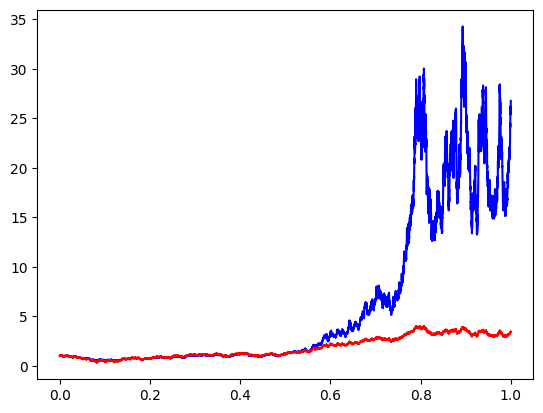

In [18]:
a, b = 0, 10000
path = 1
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 0], color = "blue")
plt.plot(solutions.ts[path, a : b], solutions.ys[path, a : b, 1], color = "red")

Next: 

- There is a mistake: we are simulating Stratonovich, not Ito. Check this is true.
- Solving $V$ first in Strat form and then $S$ in Ito form separately (step size same as brownian).
- What about solving together with lead-lag, is this even possible? Understand exactly what the lead-lag scheme is doing in the classical case

- Write code for producing 2 or 3 brownian motions with arbitrary correlation structure
- Consider the above models in this case
